# Support-Vector Networks

Replication of Cortes and Vapnik (1995), *Support-Vector Networks*, Machine Learning 20.

We reproduce the two central ideas of the paper. First, the linear support-vector machine
finds the maximum-margin separating hyperplane, with the solution supported by a small set
of training points (the support vectors). Second, the kernel trick lets the same algorithm
build non-linear decision surfaces: an RBF-kernel SVM separates data that no linear boundary
can. We visualize the margin and support vectors, and compare linear vs kernel SVM accuracy
on a non-linearly-separable problem.

In [1]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_blobs, make_circles
from sklearn.model_selection import train_test_split
rng = 0

In [2]:
# Linearly separable data; fit a linear SVM and inspect the margin.
Xb, yb = make_blobs(n_samples=80, centers=2, cluster_std=1.1, random_state=6)
lin = SVC(kernel="linear", C=10).fit(Xb, yb)
print("number of support vectors:", lin.n_support_.sum(), "of", len(Xb), "points")
print("training accuracy:", lin.score(Xb, yb))

number of support vectors: 2 of 80 points
training accuracy: 1.0


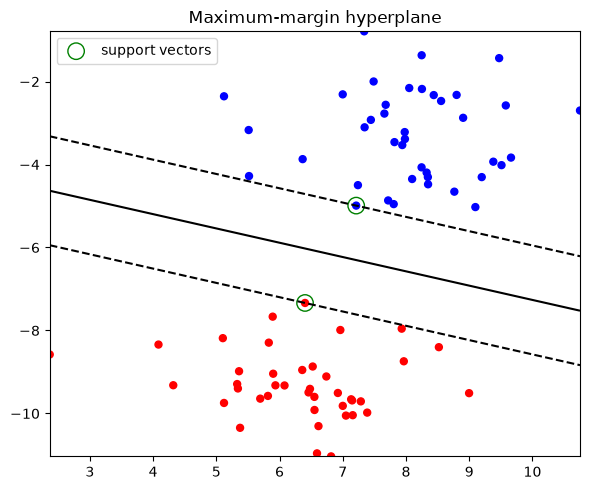

In [3]:
# Visualize maximum-margin hyperplane and the support vectors.
ax = plt.figure(figsize=(6,5)).gca()
ax.scatter(Xb[:,0], Xb[:,1], c=yb, cmap="bwr", s=25)
xx = np.linspace(Xb[:,0].min(), Xb[:,0].max(), 30)
yy = np.linspace(Xb[:,1].min(), Xb[:,1].max(), 30)
YY, XX = np.meshgrid(yy, xx)
Z = lin.decision_function(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)
ax.contour(XX, YY, Z, levels=[-1,0,1], linestyles=["--","-","--"], colors="k")
ax.scatter(lin.support_vectors_[:,0], lin.support_vectors_[:,1], s=140,
           facecolors="none", edgecolors="g", label="support vectors")
ax.legend(); ax.set_title("Maximum-margin hyperplane"); plt.tight_layout(); plt.show()

In [4]:
# Non-linearly separable data: linear SVM fails, RBF kernel succeeds.
Xc, yc = make_circles(n_samples=300, factor=0.4, noise=0.1, random_state=rng)
Xtr, Xte, ytr, yte = train_test_split(Xc, yc, test_size=0.3, random_state=rng)
acc_lin = SVC(kernel="linear").fit(Xtr, ytr).score(Xte, yte)
acc_rbf = SVC(kernel="rbf", C=1, gamma="scale").fit(Xtr, ytr).score(Xte, yte)
print(f"linear-kernel test accuracy: {acc_lin*100:.1f}%")
print(f"RBF-kernel    test accuracy: {acc_rbf*100:.1f}%")

linear-kernel test accuracy: 41.1%
RBF-kernel    test accuracy: 100.0%


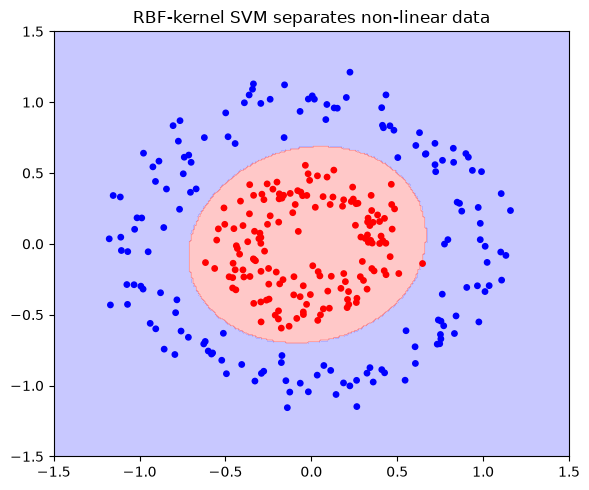

In [5]:
rbf = SVC(kernel="rbf", C=1).fit(Xc, yc)
xx, yy = np.meshgrid(np.linspace(-1.5,1.5,300), np.linspace(-1.5,1.5,300))
Z = rbf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.figure(figsize=(6,5)); plt.contourf(xx, yy, Z, alpha=0.25, cmap="bwr")
plt.scatter(Xc[:,0], Xc[:,1], c=yc, cmap="bwr", s=15)
plt.title("RBF-kernel SVM separates non-linear data"); plt.tight_layout(); plt.show()